In [1]:
import pandas as pd
import numpy as np


# Load Dataset

In [2]:
df = pd.read_csv("dataset/machine_event.csv", sep=';')
df.head()

,date,machine,event,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9
0,01/01/2015,S1F01085,0,0,7,407438,215630672,6,0,52,56,0
1,01/01/2015,S1F0166B,0,3,0,403174,61370680,6,0,0,0,0
2,01/01/2015,S1F01E6Y,0,0,0,237394,173295968,12,0,0,0,0
3,01/01/2015,S1F01JE0,0,0,0,410186,79694024,6,0,0,0,0
4,01/01/2015,S1F01R2B,0,0,3,313173,135970480,15,0,0,0,0


# Data Exploration

In [3]:
# check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   date      124494 non-null  object
 1   machine   124494 non-null  object
 2   event     124494 non-null  int64 
 3   feature1  124494 non-null  int64 
 4   feature2  124494 non-null  int64 
 5   feature3  124494 non-null  int64 
 6   feature4  124494 non-null  int64 
 7   feature5  124494 non-null  int64 
 8   feature6  124494 non-null  int64 
 9   feature7  124494 non-null  int64 
 10  feature8  124494 non-null  int64 
 11  feature9  124494 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 11.4+ MB


**No missing values detected. "date" field datatype is incorrect.**

In [4]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   date      124494 non-null  datetime64[ns]
 1   machine   124494 non-null  object        
 2   event     124494 non-null  int64         
 3   feature1  124494 non-null  int64         
 4   feature2  124494 non-null  int64         
 5   feature3  124494 non-null  int64         
 6   feature4  124494 non-null  int64         
 7   feature5  124494 non-null  int64         
 8   feature6  124494 non-null  int64         
 9   feature7  124494 non-null  int64         
 10  feature8  124494 non-null  int64         
 11  feature9  124494 non-null  int64         
dtypes: datetime64[ns](1), int64(10), object(1)
memory usage: 11.4+ MB


In [5]:
# check date range
print(f'{df['date'].min()} to {df['date'].max()}')

2015-01-01 00:00:00 to 2015-11-02 00:00:00


In [6]:
# check the number of machines
print(df['machine'].nunique())

1168


In [7]:
# check the distribution of events
print(df['event'].value_counts(normalize=True))
print()
print(df['event'].value_counts(normalize=False))

event
0    0.999149
1    0.000851
Name: proportion, dtype: float64

event
0    124388
1       106
Name: count, dtype: int64


**Very imbalance data. Event data is much smaller than non-event data.**

In [8]:
# check the distribution of features
features = [f'feature{i}' for i in range(1, 10)]
X = df[features]
y = df['event']

X.describe()

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9
count,124494.000000,124494.000000,124494.000000,1.244940e+05,124494.000000,124494.000000,124494.000000,124494.000000,124494.000000
mean,9.940455,12.451524,260172.858025,1.223868e+08,14.222693,0.292528,1.741120,159.484762,0.438792
std,185.747321,191.425623,99151.009852,7.045960e+07,15.943021,7.436924,22.908507,2179.657730,11.155386
min,0.000000,0.000000,8.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,221452.000000,6.127675e+07,8.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,249799.500000,1.227957e+08,10.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,310266.000000,1.833084e+08,12.000000,0.000000,0.000000,0.000000,0.000000
max,24929.000000,18701.000000,689161.000000,2.441405e+08,98.000000,832.000000,1666.000000,64968.000000,1248.000000


**Feature3 and Feature4 has very large values.**

In [9]:
# check the machine count descriptions
machine_counts = df['machine'].value_counts()
print(f"Number of machine with single entry: {(machine_counts == 1).sum()}")
print(f"Average row per machine: {machine_counts.mean()}")

Number of machine with single entry: 0
Average row per machine: 106.58732876712328


# Feature Engineering

In [10]:
from sklearn.ensemble import IsolationForest

In [11]:
# extract date information as new features
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['month'] = df['date'].dt.month

In [12]:
df_eng = df.drop(['date', 'machine'], axis=1)
df_eng.head()

,event,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,day_of_week,day_of_month,month
0,0,0,7,407438,215630672,6,0,52,56,0,3,1,1
1,0,3,0,403174,61370680,6,0,0,0,0,3,1,1
2,0,0,0,237394,173295968,12,0,0,0,0,3,1,1
3,0,0,0,410186,79694024,6,0,0,0,0,3,1,1
4,0,0,3,313173,135970480,15,0,0,0,0,3,1,1


# Data Preparation

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [14]:
target_col = 'event'

X = df_eng.drop(columns=[target_col])
y = df_eng[target_col]

X.shape, y.shape

((124494, 12), (124494,))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((99595, 12), (24899, 12), (99595,), (24899,))

In [16]:
iso = IsolationForest(
    contamination=0.001,
    n_estimators=300,
    random_state=42
)
iso.fit(X_train)

X_train["iso_score"] = -iso.decision_function(X_train)
X_test["iso_score"] = -iso.decision_function(X_test)

In [17]:
X_train

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,day_of_week,day_of_month,month,iso_score
73169,0,0,245331,86639208,58,0,0,0,0,2,22,4,-0.283628
89016,0,0,53,42902464,16,0,0,0,0,3,4,6,-0.249294
96519,0,0,269706,119550760,10,0,0,408,0,4,26,6,-0.288396
38893,0,0,196804,145173112,9,0,0,0,0,4,20,2,-0.330316
104352,0,12,362209,38928312,8,0,0,0,0,5,18,7,-0.283294
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87761,0,0,279571,179232680,12,0,0,0,0,0,1,6,-0.286792
38133,0,1,321391,230740472,6,0,0,0,0,3,19,2,-0.308343
97446,0,1,249287,39684656,57,0,6,0,0,6,28,6,-0.199387
83308,0,0,259823,199332928,8,0,0,48,0,1,19,5,-0.309013


In [18]:
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)

In [19]:
X_res = X_train
y_res = y_train

# # balancing class using SMOTE
# smote = SMOTE(random_state=42)
# X_res, y_res = smote.fit_resample(X_train_scaled, y_train)
# X_res.shape, y_res.shape

In [20]:
counts = np.bincount(y_res)
counts

array([99510,    85])

# Modeling

In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

## XGBoost

### Grid Search

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
}

In [23]:
ratio = np.sum(y_res == 0) / np.sum(y_res == 1)
print(f"Ratio of imbalance: {ratio}")

xgb_grid = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='aucpr'
)

Ratio of imbalance: 1170.7058823529412


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    verbose=1,
    n_jobs=-1
)
# grid_search.fit(X_res, y_res)
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best Score: {grid_search.best_score_}")

In [25]:
# Modeling after Grid Search CV
# Best Parameters: {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 200, 'subsample': 0.8}
# Best Score: 0.08080815989098042

final_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=15,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='aucpr',
)
final_xgb.fit(X_res, y_res)

cv_scores = cross_val_score(final_xgb, X_res, y_res, 
    cv=cv, scoring='average_precision', n_jobs=-1)
cv_scores

array([0.03320398, 0.13300253, 0.20490164, 0.02312749, 0.03966488])

### Random Forest

In [26]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4],
}

In [27]:
rf_grid = RandomForestClassifier(
    class_weight={0: 1, 1: ratio},
    random_state=42,
)

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    verbose=1,
    n_jobs=-1
)
# grid_search.fit(X_res, y_res)
# print(f"Best Parameters: {grid_search.best_params_}")
# print(f"Best Score: {grid_search.best_score_}")

In [29]:
# Modeling after Grid Search CV
# Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
# Best Score: 0.0755456514023979

final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
)
final_rf.fit(X_res, y_res)

cv_scores = cross_val_score(final_rf, X_res, y_res, 
    cv=cv, scoring='average_precision', n_jobs=-1)
cv_scores

array([0.02902976, 0.09145776, 0.11540466, 0.0529301 , 0.07986414])

# Evaluation

In [30]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score, average_precision_score
)
import matplotlib.pyplot as plt

In [31]:
y_pred_proba = final_xgb.predict_proba(X_test)[:, 1]

In [32]:
thresholds = np.linspace(0, 1, 500)

best_t = None
best_f1 = float("-inf")

for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t)
print(best_f1)

0.022044088176352703
0.18867924528301888


In [33]:
threshold = 0.0220
# threshold = 0.0841
y_pred = (y_pred_proba >= threshold).astype(int)

In [34]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

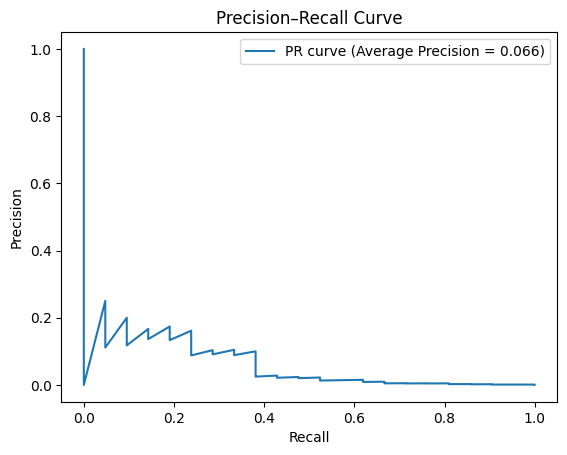

In [35]:
plt.figure()
plt.plot(recall, precision, label=f"PR curve (Average Precision = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

In [36]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Event', 'Event']))


Classification Report:
              precision    recall  f1-score   support

    No Event       1.00      1.00      1.00     24878
       Event       0.16      0.24      0.19        21

    accuracy                           1.00     24899
   macro avg       0.58      0.62      0.59     24899
weighted avg       1.00      1.00      1.00     24899



In [37]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual No Event', 'Actual Event'], columns=['Predicted No Event', 'Predicted Event'])
print(cm_df)


Confusion Matrix:
                 Predicted No Event  Predicted Event
Actual No Event               24851               27
Actual Event                     16                5


# Feature Importance

In [38]:
importances = final_xgb.feature_importances_
feature_names = df_eng.drop('event', axis=1).columns.tolist()
feature_names.append('iso_score')

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

print(df_importance)

         Feature  Importance
5       feature6    0.230456
6       feature7    0.123141
0       feature1    0.115784
7       feature8    0.103861
9    day_of_week    0.064515
12     iso_score    0.062938
11         month    0.056696
10  day_of_month    0.051343
4       feature5    0.050634
2       feature3    0.049727
1       feature2    0.045477
3       feature4    0.045427
8       feature9    0.000000


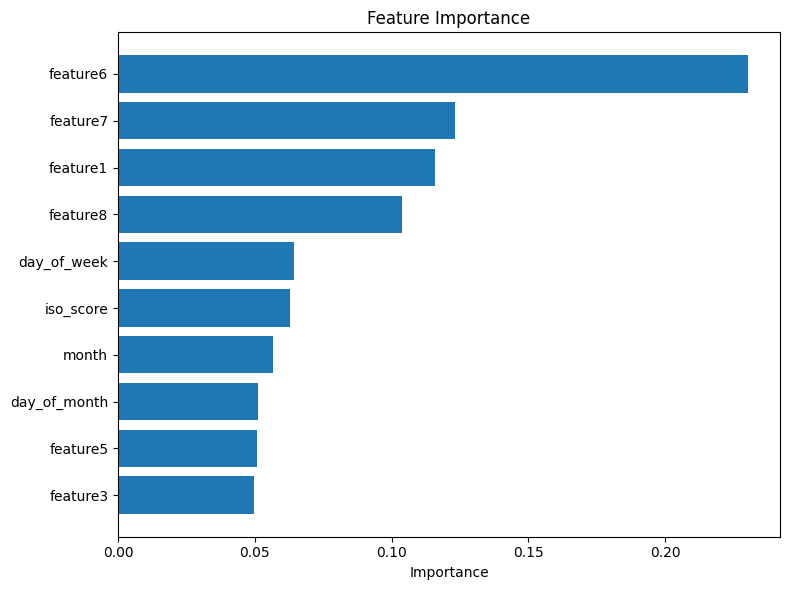

In [39]:
plt.figure(figsize=(8, 6))
plt.barh(
    df_importance["Feature"][:10][::-1],
    df_importance["Importance"][:10][::-1]
)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [40]:
booster = final_xgb.get_booster()

gain_importance = booster.get_score(importance_type="gain")

In [41]:
df_gain = (
    pd.DataFrame(
        gain_importance.items(),
        columns=["Feature", "Gain"]
    )
    .sort_values(by="Gain", ascending=False)
)

print(df_gain.head(10))

         Feature      Gain
5       feature6  5.184618
6       feature7  2.770328
0       feature1  2.604822
7       feature8  2.336583
8    day_of_week  1.451401
11     iso_score  1.415929
10         month  1.275511
9   day_of_month  1.155077
4       feature5  1.139124
2       feature3  1.118711
